# 인공신경망

## 환경설정 및 이론

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris, load_diabetes, load_breast_cancer
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score
from sklearn.svm import SVC, SVR
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from matplotlib import pyplot as plt

In [3]:
# MLPClassifier(

# * hidden_layer_sizes=(100,),  은닉층(Hidden Layer)의 구조를 결정 // (100, 50, 30) 1층에 100개, 2층에 50개, 3층에 30개
# activation='relu',            활성화 함수(Activation Function)를 정함
# solver='adam',                가중치를 업데이트하는 수학적 최적화 알고리즘
# alpha=0.0001,                 가중치가 너무 커져서 특정 데이터에만 과하게 집착하는 것(과적합)을 방지하기 위한 L2 규제. 값이 클수록 모델이 단순해짐
# batch_size='auto',            데이터를 한 번에 몇 개씩 묶어서 공부하고 오차를 수정할지 정합니다
# learning_rate='constant',     학습률 설정 / 공부 보폭을 끝까지 일정하게 유지할지(constant), 학습이 진행될수록 조금씩 줄여나갈지(adaptive)
# learning_rate_init=0.001,     첫 학습률 크기
# power_t=0.5, 
# max_iter=200,                 최대 몇 번 반복(Epoch) 학습할 것인가를 정함
# shuffle=True,                 매번 순서를 섞어서 외우지 못하게(과적합 방지) 방해
# random_state=None, 
# tol=0.0001,                   오차가 개선되는 최소 기준
# verbose=False, 
# warm_start=False,             이전에 학습했던 결과 가중치를 그대로 이어받아서 추가로 학습
# momentum=0.9, 
# nesterovs_momentum=True, 
# early_stopping=False,         조기 종료 기능. True로 바꾸면 전체 데이터 중 일부(validation_fraction=0.1, 즉 10%)를 따로 빼놓고 모의고사를 치르면서, 점수가 떨어지기 시작하면 과적합으로 판단하고 중간에 학습을 끊어버림
# validation_fraction=0.1, 
# beta_1=0.9, 
# beta_2=0.999, 
# epsilon=1e-08, 
# n_iter_no_change=10,          성능 개선이 없는 상태가 연속으로 10번 지속되면 학습을 강제 종료
# max_fun=15000)

## 1. 활성화 함수 (Activation): ReLU vs Sigmoid

활성화 함수는 이전 층에서 넘어온 데이터를 어떤 형태로 변환해서 넘길지 결정하는 역할을 합니다.

### 1) Sigmoid (시그모이드)

- **특징**: 모든 숫자를 0과 1 사이의 부드러운 곡선으로 압축. 음수는 0에 가깝게, 양수는 1에 가깝게 만듭니다.
- **용도**: 결과값이 0~1 사이의 '확률'로 나와야 하는 이진 분류.
- **단점 (은닉층에서 안 쓰는 이유)**: 신경망이 깊어질수록 값을 계속 0~1 사이로 짓누르다 보니, 나중에는 데이터의 특징(기울기)이 희미해져서 학습이 멈춰버리는 **기울기 소실(Vanishing Gradient)** 발생.

### 2) ReLU (렐루, Rectified Linear Unit)

- **특징**: 단순. 음수면 그냥 0으로 없애버리고, 양수면 그 숫자 그대로 통과시킴 (`max(0, x)`).
- **용도**: 은닉층(Hidden Layer)의 표준(Standard). 특별한 이유가 없다면 ReLU를 사용.
- **장점**: 계산 속도가 엄청나게 빠르고, 기울기 소실 문제를 완벽하게 해결하여 신경망을 수십, 수백 층으로 쌓을 수 있게 함.

---

## 2. 손실 함수 (Loss): MSE vs Binary Crossentropy 등

손실 함수는 모델이 정답을 맞히고 나서 채점하는 오차 계산법입니다.

### 1) MSE (Mean Squared Error, 평균 제곱 오차)

- **사용 시기**: 회귀 문제 (집값 예측, 온도 예측 등 구체적인 연속된 '숫자'를 맞힐 때)
- **특징**: 실제 정답 수치와 모델이 예측한 수치의 차이를 제곱하여 평균. 오차가 클수록 페널티를 기하급수적으로 크게 줍니다.

### 2) Binary Crossentropy (이진 교차 엔트로피)

- **사용 시기**: 이진 분류 문제 (암 양성/악성, 스팸메일 O/X 등 2개 중 하나를 고를 때)
- **특징**: 확률 기반. 정답이 1(암)인데 모델이 0.1(10%)이라고 예측했다면 큰 페널티를, 0.9(90%)라고 예측했다면 작은 벌점을 줍니다.

### 3) Categorical Crossentropy (다중 교차 엔트로피) — 번외

- **사용 시기**: 다중 분류 문제 (개/고양이/새 중 하나 맞히기, 아이리스 꽃 3종류 분류 등 정답이 3개 이상일 때)

---

## 3. 최적화 알고리즘 (Optimizer): SGD vs Adam

최적화 알고리즘은 손실 함수로 계산된 오차를 바탕으로 어떻게 하면 가장 빠르고 안전하게 오차를 0(최적의 가중치)으로 줄여나갈지 결정하는 엔진입니다.

### 1) SGD (Stochastic Gradient Descent, 확률적 경사 하강법)

- **특징**: 가장 기본적이고 고전적인 방식. 현재 서 있는 위치에서 경사(기울기)가 제일 가파른 쪽으로 지정된 단위씩 정직하게 내려갑니다.
- **단점**: 보폭(학습률)이 고정되어 있어서 복잡한 데이터에서는 이리저리 튀거나, 움푹 파인 특정 최소값(Local Minima)으로 길을 잃는 경우가 발생. 속도도 느림.

### 2) Adam (Adaptive Moment Estimation)

- **특징**: 현재 딥러닝계의 압도적인 방식. 관성(Momentum)과 적응적 학습률(Adaptive, 경사가 완만하면 보폭을 크게, 가파르면 보폭을 작게 조절) 두 가지 고급 기술을 모두 합친 알고리즘.
- **장점**: 방향을 잃지 않고 아주 부드럽고 빠르게 최적점을 찾아갑니다. 실무에서는 무조건 `optimizer='adam'`을 기본값으로 깔고 시작합니다.

## 1. IRIS 데이터 실습

In [2]:
# 실습 1-0 데이터 불러오기

iris = load_iris()

x_train, x_test, y_train, y_test = train_test_split(iris.data, iris.target, stratify=iris.target,random_state=260706)

scaler = StandardScaler()
x_train_zs = scaler.fit_transform(x_train)
x_test_zs = scaler.transform(x_test)

In [3]:
# 실습 1-1 신경망 분석

iris_nn = MLPClassifier((10,50,10), max_iter = 500)
iris_nn.fit(x_train_zs, y_train)
pred = iris_nn.predict(x_test_zs)


print(accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))

0.9736842105263158
[[13  0  0]
 [ 0 12  1]
 [ 0  0 12]]


In [4]:
# 실습 1-2 예측할 확률

iris_nn.predict_proba(x_test_zs)  # 0번일 확률, 1번일 확률, 2번일 확률

array([[9.99247038e-01, 7.40671219e-04, 1.22906882e-05],
       [5.50358780e-08, 1.41059632e-06, 9.99998534e-01],
       [5.66109197e-03, 9.94248523e-01, 9.03854807e-05],
       [5.38315038e-03, 9.84111246e-01, 1.05056033e-02],
       [3.35305456e-03, 9.95600408e-01, 1.04653760e-03],
       [2.38324935e-04, 9.09614336e-03, 9.90665532e-01],
       [7.02558282e-07, 1.34769031e-05, 9.99985821e-01],
       [9.98192842e-01, 1.74716187e-03, 5.99962995e-05],
       [4.14366428e-07, 7.16405839e-06, 9.99992422e-01],
       [9.94519028e-01, 5.39226228e-03, 8.87102196e-05],
       [4.97400668e-03, 9.92854948e-01, 2.17104539e-03],
       [9.98923980e-01, 1.02791470e-03, 4.81051152e-05],
       [4.25559826e-03, 9.88418840e-01, 7.32556208e-03],
       [2.20479179e-03, 9.95274386e-01, 2.52082232e-03],
       [1.70407742e-07, 4.86209400e-06, 9.99994967e-01],
       [7.11492181e-03, 9.92580561e-01, 3.04517668e-04],
       [9.94614400e-01, 5.31327185e-03, 7.23282349e-05],
       [6.55943232e-03, 1.85682

## 2. Breast Cancer 실습

In [ ]:
# 실습 2-0 데이터 불러오기

bc = load_breast_cancer()

x_train, x_test, y_train, y_test = train_test_split(bc.data, bc.target, stratify=bc.target,random_state=260706)

scaler = StandardScaler()
x_train_zs = scaler.fit_transform(x_train)
x_test_zs = scaler.transform(x_test)

In [ ]:
# 실습 2-1 신경망 분석

bc_nn = MLPClassifier((64,128,64))
bc_nn.fit(x_train_zs, y_train)
pred = bc_nn.predict(x_test_zs)


print(accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))

0.965034965034965
[[51  2]
 [ 3 87]]


In [ ]:
# 실습 2-2 예측할 확률
bc_nn.predict_proba(x_test_zs) # 0번일 확률, 1번일 확률

array([[2.61371172e-05, 9.99973863e-01],
       [4.50849153e-06, 9.99995492e-01],
       [2.31703257e-05, 9.99976830e-01],
       [9.99963266e-01, 3.67337061e-05],
       [2.74819555e-04, 9.99725180e-01],
       [2.48314769e-04, 9.99751685e-01],
       [3.84021025e-05, 9.99961598e-01],
       [9.99999705e-01, 2.94920979e-07],
       [9.99943826e-01, 5.61744036e-05],
       [9.99999997e-01, 3.20419114e-09],
       [4.46302215e-08, 9.99999955e-01],
       [1.33630884e-09, 9.99999999e-01],
       [9.99999997e-01, 3.22379667e-09],
       [2.16802618e-08, 9.99999978e-01],
       [9.99999995e-01, 5.17441056e-09],
       [9.16909449e-06, 9.99990831e-01],
       [0.00000000e+00, 1.00000000e+00],
       [1.00000000e+00, 3.80927737e-16],
       [3.88120650e-06, 9.99996119e-01],
       [8.19193896e-05, 9.99918081e-01],
       [1.01224750e-06, 9.99998988e-01],
       [9.99997858e-01, 2.14165858e-06],
       [2.36777087e-09, 9.99999998e-01],
       [4.35518279e-06, 9.99995645e-01],
       [4.095675

## 3. 당뇨병 데이터를 통한 수치예측 모델

In [20]:
# 실습 3-0 데이터 불러오기
dibt = load_diabetes()
x_train, x_test, y_train, y_test = train_test_split(dibt.data, dibt.target, random_state=260706)
scaler = StandardScaler()
x_train_zs = scaler.fit_transform(x_train)
x_test_zs = scaler.transform(x_test)

In [10]:
dibt_nn = MLPRegressor(hidden_layer_sizes=(64,128,64), max_iter=2000)
dibt_nn.fit(x_train_zs, y_train)
pred = dibt_nn.predict(x_test_zs)

print(mean_squared_error(y_test, pred))


7327.879567441562


In [11]:
# 실습 3-1 Diabetes 데이터를 이용하여 knn, nb, dt, rf, ab, le, lr, svm, mlp 모델링하고, CV 로 MSE 성능 비교

# x_train, x_test, y_train, y_test = train_test_split(dibt.data, dibt.target, random_state=42)


# split = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

# pipe = Pipeline([
#     ('preprocess', StandardScaler()),
#     ('regressor', LinearRegression())
# ])

# param_grid = [
#     # KNN
#     {'preprocess': [StandardScaler()],
#      'regressor': [KNeighborsRegressor()],
#      'regressor__n_neighbors': [3, 5, 7, 9],
#      'regressor__weights': ['uniform', 'distance']},

#     # Naive Bayes
#     {'preprocess': [None],
#      'regressor': [GaussianNB()]},

#     # Decision Tree
#     {'preprocess': [None],
#      'regressor': [DecisionTreeRegressor(random_state=42)],
#      'regressor__max_depth': [3, 5, 7, None]},

#     # Random Forest
#     {'preprocess': [None],
#      'regressor': [RandomForestRegressor(random_state=42)],
#      'regressor__n_estimators': [50, 100, 200]},

#     # AdaBoost
#     {'preprocess': [None],
#      'regressor': [AdaBoostRegressor(random_state=42)],
#      'regressor__n_estimators': [50, 100, 200],
#      'regressor__learning_rate': [0.01, 0.1, 1.0]},

#     # Linear Regression
#     {'preprocess': [StandardScaler()],
#      'regressor': [LinearRegression()]},

#      # SVM
#      {'preprocess': [StandardScaler()],
#       'regressor': [SVR()],
#       'regressor__kernel': ['linear'],
#       'regressor__C': [0.01, 1, 10, 100]},

#      {'preprocess': [StandardScaler()],
#       'regressor': [SVR()],
#       'regressor__kernel': ['rbf'],
#       'regressor__gamma': [0.1, 1, 10, 50, 100],
#       'regressor__C': [0.01, 1, 10, 100]},

#     # MLP
#     {'preprocess': [StandardScaler()],
#      'regressor': [MLPRegressor(max_iter=5000, random_state=42)],
#      'regressor__tol': [0.01,1,10],
#      'regressor__hidden_layer_sizes': [(50,), (100,), (64,128,64)]},
# ]

# grid = GridSearchCV(pipe,
#                     param_grid,
#                     cv=10,
#                     scoring='neg_mean_squared_error',
#                     return_train_score=True,
#                     verbose=3)

# grid.fit(x_train, y_train)

# print(grid.best_params_)
# print('Best CV MSE:', -grid.best_score_)

# pred = grid.best_estimator_.predict(x_test)
# print('Test MSE:', mean_squared_error(y_test, pred))

In [ ]:
## split = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42) 인 경우

# {'preprocess': StandardScaler(), 'regressor': LinearRegression()}
# Best CV MSE: 3195.3522861832043
# Test MSE: 2848.310650847506

## cv = 10 인경우

# {'preprocess': StandardScaler(), 'regressor': LinearRegression()}
# Best CV MSE: 3130.7729609548874
# Test MSE: 2848.310650847506

## 4. Dense 레이어 // FCL

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 14637.4082 - mae: 97.9100 - mse: 14637.4082 - val_loss: 6782.8374 - val_mae: 65.1618 - val_mse: 6782.8374
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 5437.7319 - mae: 62.1650 - mse: 5437.7319 - val_loss: 8907.8525 - val_mae: 69.6976 - val_mse: 8907.8525
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5369.8999 - mae: 61.4025 - mse: 5369.8999 - val_loss: 4819.0327 - val_mae: 56.3077 - val_mse: 4819.0327
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 3665.5906 - mae: 50.7961 - mse: 3665.5906 - val_loss: 4353.6777 - val_mae: 52.5764 - val_mse: 4353.6777
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3380.9736 - mae: 47.7061 - mse: 3380.9736 - val_loss: 4550.3428 - val_mae: 53.2570 - val_mse: 4550.3428
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3382.8833 - mae: 48.0729 - mse: 3382.8833 - val_loss: 4007.4221 - val_mae: 50.2852 - val_mse: 4007.4221
Epoch 7/100
11

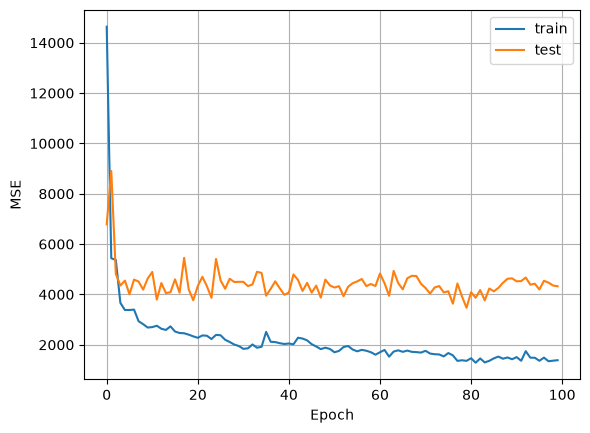

In [ ]:
# 실습 4-1 MLPRegressor 재현

model = Sequential()
model.add(Input(shape=(10,)))              # 데이터 shape // 데이터 입구
model.add(Dense(16, activation='sigmoid')) # 16개 노드 / 0,1 값인 시그모이드로 변환
model.add(Dense(8, activation='sigmoid'))  # 16개 노드 / 0,1 값인 시그모이드로 변환
model.add(Dense(1))                        # 최종 결과값
model.summary()

# Param = (입력 노드 수 * 현재 층 노드 수) + 현재 층 노드 수

# MLPRegressor((16,8)) 과 동일
                   
model.compile(loss='mse',            # 오차를 계산하는 기준 
              optimizer='sgd',       # 오차를 줄이는 방법 / Stochastic Gradient Descent(확률적 경사 하강법)
              metrics=['mae','mse']) # 답을 보여주는 방식

hist =model.fit(x_train_zs, y_train, 
          validation_data=(x_test_zs, y_test), # 검증 데이터(Validation set)를 지정 // 에폭(Epoch)이 하나씩 끝날 때마다 검증 데이터와의 오차 계산
          epochs=100)

plt.plot(hist.history['loss'], label='train')
plt.plot(hist.history['val_loss'], label='test')
plt.legend(loc='best')
plt.grid()
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.show()


In [36]:
pred = model.predict(x_test_zs)
print(pred[:5])
print(y_test[:5])

r2 = r2_score(y_test, pred)
print('R2 score:', r2)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
[[206.73766]
 [ 71.31751]
 [273.43732]
 [163.75584]
 [118.95371]]
[100.  75. 274.  68.  67.]
R2 score: 0.35138016957605156


## R² Score란 무엇인가?

모델이 데이터를 얼마나 똑똑하게 예측하는지 0에서 1 사이의 점수로 환산한 것.

**수식 개념**:

$$R^2 = 1 - \frac{모델의 오차}{평균으로 예측했을 때의 오차}$$

---

## R² Score 읽는 법

- **R² = 1.0 (최고점)**: 완벽. 모델이 데이터의 모든 변동을 설명. 실무에선 점수가 오히려 너무 높아서 '과적합'을 의심해봐야 함.
- **R² = 0.0 (기준점)**: 차악. 모델이 데이터를 하나도 설명하지 못함.
- **R² < 0 (음수)**: 최악. 모델이 단순히 평균값으로 예측하는 것보다도 더 못한 수치. 모델 구조나 데이터 처리에 심각한 문제 있을 것.
- **일반적인 점수**: 분야마다 다르지만, 0.7~0.8 이상이면 "데이터의 패턴을 꽤 잘 찾아내고 있구나"라고 평가.

## 5. BC 데이터로 Dense 레이어 적용

In [ ]:
# 실습 5-1 BC 데이터로 Dense Layer를 이용한 신경망 모델링

bc = load_breast_cancer()
x_train, x_test, y_train, y_test = train_test_split(bc.data, bc.target, test_size=0.2, random_state=260706)
scaler = StandardScaler()
x_train_zs = scaler.fit_transform(x_train)
x_test_zs = scaler.transform(x_test)

# 신경망 모델 설계
model = Sequential()
model.add(Input(shape=(30,)))             # 속성이 30개
model.add(Dense(16, activation='relu'))   # 은닉층
model.add(Dense(8, activation='relu'))    # 은닉층
model.add(Dense(1, activation='sigmoid')) # 이진 분류이므로 결과값은 0~1 사이 확률로 내보내는 sigmoid
model.summary()

'''
노드의 과적합이란?

학습할 때 모델이 훈련 데이터에 너무 잘 맞춰져서 새로운 데이터에는 잘 작동하지 않는 상태
즉, 출제된 모든 기출문제의 답을 외워서 시험을 치르는 것과 같음

'''
# 모델 학습 규칙
model.compile(loss='binary_crossentropy', # 이진 분류 오차 계산법
              optimizer='adam',           # sgd보다 성능이 좋음
              metrics=['accuracy'])       # 정확도 보기

# 학습 진행
hist = model.fit(x_train_zs, y_train, 
                 validation_data=(x_test_zs, y_test), # 모의고사 데이터
                 epochs=100)

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.5802 - loss: 0.7072 - val_accuracy: 0.8158 - val_loss: 0.6121
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8220 - loss: 0.5690 - val_accuracy: 0.9211 - val_loss: 0.5158
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9099 - loss: 0.4725 - val_accuracy: 0.9474 - val_loss: 0.4432
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9297 - loss: 0.3993 - val_accuracy: 0.9298 - val_loss: 0.3828
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9429 - loss: 0.3377 - val_accuracy: 0.9386 - val_loss: 0.3293
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9473 - loss: 0.2853 - val_accuracy: 0.9298 - val_loss: 0.2761
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9538 - loss: 0.2405 - val_accuracy: 0.9298 - val_loss: 0.2323
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9560 - loss: 0.2047 - val_accuracy: 0.

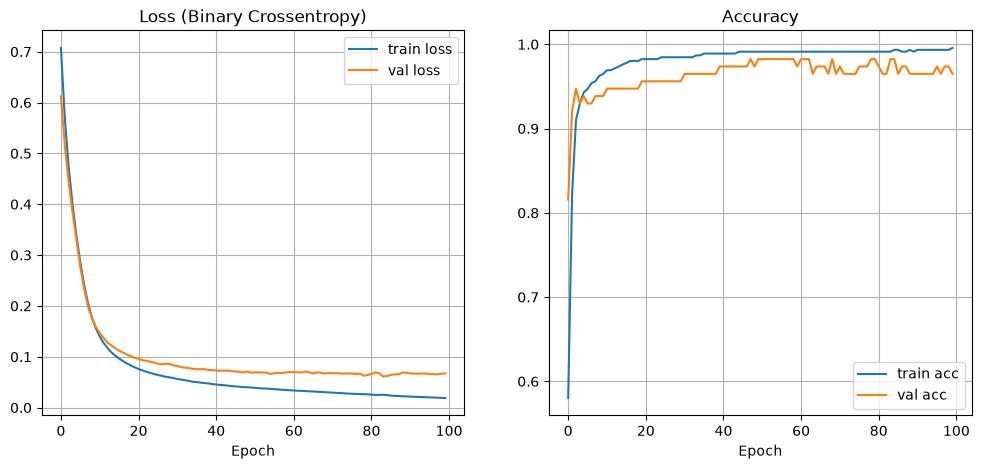

In [ ]:
# 실습 5-2 그래프 그리기

plt.figure(figsize=(12, 5)) # 그래프 틀

# 오차(Loss) 그래프 - 줄어들수록 좋음
plt.subplot(1, 2, 1)
plt.plot(hist.history['loss'], label='train loss')
plt.plot(hist.history['val_loss'], label='val loss')
plt.legend()
plt.grid()
plt.title('Loss (Binary Crossentropy)')
plt.xlabel('Epoch')

# 정확도(Accuracy) 그래프 - 올라갈수록 좋음
plt.subplot(1, 2, 2)
plt.plot(hist.history['accuracy'], label='train acc')
plt.plot(hist.history['val_accuracy'], label='val acc')
plt.legend()
plt.grid()
plt.title('Accuracy')
plt.xlabel('Epoch')

plt.show()